# Sleep Quality Evaluation Notebook

Re-evaluation of the sleep-quality classifier with fairness and Class 4 viability diagnostics.


In [2]:
# Core imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from scipy.stats import beta

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 10,
})


## 1. Data Loading
Confirm sample size, feature availability, and class imbalance before modeling; ensures later splits and fairness slices are interpretable.


In [3]:
DATA_PATH = "DataSets/ScreenTime vs MentalWellness.csv"
TARGET_COL = "sleep_quality_1_5"
LEAKAGE_FEATURES = ["sleep_hours"]  # cannot know tonight's sleep duration at prediction time
ID_COLS = ["user_id"]

raw_df = pd.read_csv(DATA_PATH).drop(columns=["Unnamed: 15"])
print(f"Dataset shape: {raw_df.shape}")
print("Class distribution (full dataset):")
print(raw_df[TARGET_COL].value_counts().sort_index())
raw_df.head()


Dataset shape: (400, 15)
Class distribution (full dataset):
sleep_quality_1_5
1    275
2     94
3     28
4      3
Name: count, dtype: int64


,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


**Observations (data readiness)**

The dataset contains 400 samples with severe class imbalance: Class 1 (275 samples, 68.75%), Class 2 (94, 23.5%), Class 3 (28, 7%), and Class 4 (3, 0.75%). This extreme imbalance will bias standard models toward the majority class. `sleep_hours` is removed as a leakage feature since it cannot be known at prediction time, and `user_id` is kept only as an identifier. Class 4's critical underrepresentation (0.75%) will make reliable prediction nearly impossible.

## 2. Prep: Leakage Removal, Feature Typing, and Splits
Prevent temporal leakage, preserve categorical semantics, and lock in deterministic train/test partitions (320 train, 80 test) before SMOTE.


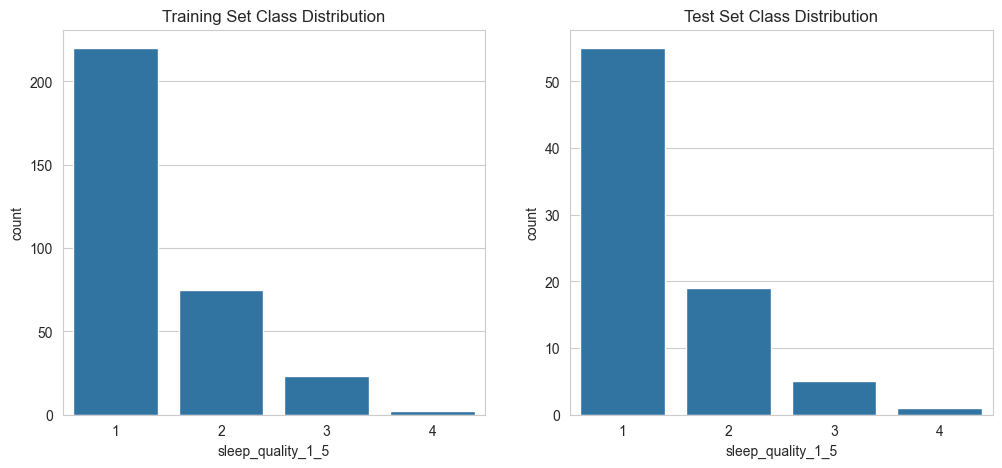

Train size: 320 Test size: 80
Train distribution: sleep_quality_1_5
1    220
2     75
3     23
4      2
Name: count, dtype: int64
Test distribution: sleep_quality_1_5
1    55
2    19
3     5
4     1
Name: count, dtype: int64
Balanced class counts:
sleep_quality_1_5
1    220
2    220
3    220
4    220
Name: count, dtype: int64


In [15]:
# Remove leakage/id columns and define feature groups
feature_df = raw_df.drop(columns=[TARGET_COL] + ID_COLS + LEAKAGE_FEATURES)
target = raw_df[TARGET_COL]

categorical_features = ["gender", "occupation", "work_mode"]
numeric_features = [col for col in feature_df.columns if col not in categorical_features]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    target,
    test_size=0.2,
    stratify=target,
    random_state=RANDOM_STATE,
)

# Plot class distribution in training  and test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Training Set Class Distribution")
sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
plt.show()

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train distribution:", y_train.value_counts().sort_index())
print("Test distribution:", y_test.value_counts().sort_index())

# Preprocess (scale numeric, one-hot categorical)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# SMOTE balancing on the preprocessed training set
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_preprocessed, y_train)

print("Balanced class counts:")
print(pd.Series(y_train_balanced).value_counts().sort_index())


**Observations (prep impact)**

Stratified split preserved class imbalance: 320 training and 80 test samples, with Class 4 split into 2 train and 1 test samples. SMOTE expanded each class to 220 samples, making Class 4 99.1% synthetic (218/220). This means the model will train primarily on artificial interpolations rather than real poor-sleep examples, making Class 4 metrics highly fragile and misleading. Preprocessing applies standardization to numeric features and one-hot encoding to categoricals.

## 3. Train / Validation / Test Evaluation
Detect overfitting by comparing balanced-train performance, 5-fold cross-validation (validation), and held-out test metrics on the original imbalance.


Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}


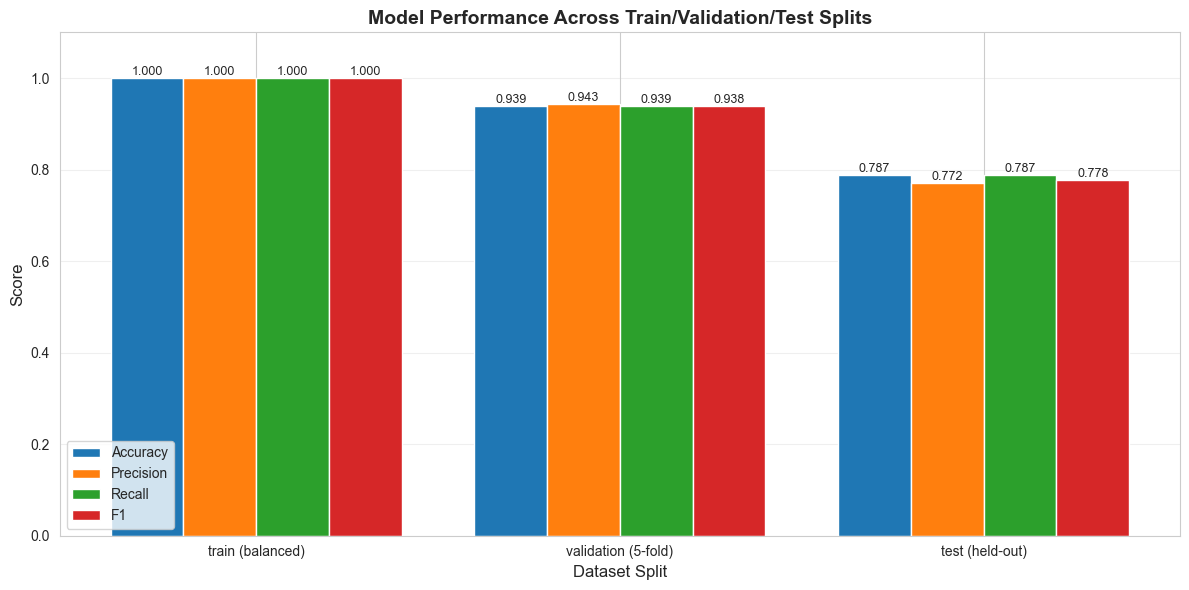


Performance Summary:
              Split  accuracy  precision  recall     f1
   train (balanced)    1.0000     1.0000  1.0000 1.0000
validation (5-fold)    0.9386     0.9429  0.9386 0.9382
    test (held-out)    0.7875     0.7716  0.7875 0.7776


In [17]:
# Gradient Boosting + grid search on balanced data
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5],
}

base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Validation via 5-fold CV using the tuned model
cv_results = cross_validate(
    best_model,
    X_train_balanced,
    y_train_balanced,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision_weighted",
        "recall": "recall_weighted",
        "f1": "f1_weighted",
    },
    n_jobs=-1,
)
validation_metrics = {
    metric.replace("test_", ""): float(np.mean(scores))
    for metric, scores in cv_results.items()
    if metric.startswith("test_")
}

# Fit on balanced train for train metrics
best_model.fit(X_train_balanced, y_train_balanced)
train_pred = best_model.predict(X_train_balanced)
train_metrics = {
    "accuracy": accuracy_score(y_train_balanced, train_pred),
    "precision": precision_score(y_train_balanced, train_pred, average="weighted"),
    "recall": recall_score(y_train_balanced, train_pred, average="weighted"),
    "f1": f1_score(y_train_balanced, train_pred, average="weighted"),
}

# Test metrics on original distribution
X_test_preprocessed = preprocessor.transform(X_test)  # ensure alignment after fitting model
class_probabilities = best_model.predict_proba(X_test_preprocessed)
y_pred = best_model.predict(X_test_preprocessed)
test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="weighted"),
    "recall": recall_score(y_test, y_pred, average="weighted"),
    "f1": f1_score(y_test, y_pred, average="weighted"),
}

metrics_report = {
    "train (balanced)": train_metrics,
    "validation (5-fold)": validation_metrics,
    "test (held-out)": test_metrics,
}

metrics_df = pd.DataFrame(metrics_report).T
metrics_df.index.name = "Split"
metrics_df = metrics_df.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df))
width = 0.2
metrics_list = ["accuracy", "precision", "recall", "f1"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (metric, color) in enumerate(zip(metrics_list, colors)):
    offset = width * (idx - 1.5)
    bars = ax.bar(x + offset, metrics_df[metric], width, label=metric.capitalize(), color=color)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Dataset Split", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Across Train/Validation/Test Splits", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Split"])
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPerformance Summary:")
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

**Observations (generalization gap)**

Perfect training performance (accuracy 1.0000, F1 1.0000) indicates memorization of synthetic SMOTE samples. Validation accuracy of 0.9386 appears promising but remains inflated by testing on synthetic data. The critical drop occurs on the held-out test set with real samples: accuracy falls to 0.7875 and F1 to 0.7776, a 21-percentage-point drop signaling severe overfitting. For a health application, this generalization gap is unacceptable and indicates the model is not deployment-ready.

## 4. ROC and Precision-Recall Diagnostics
Accuracy hides minority-class performance; ROC/PR curves surface separability and precision trade-offs per class. PR is preferred under imbalance; Class 4 is skipped (only 1 test sample).


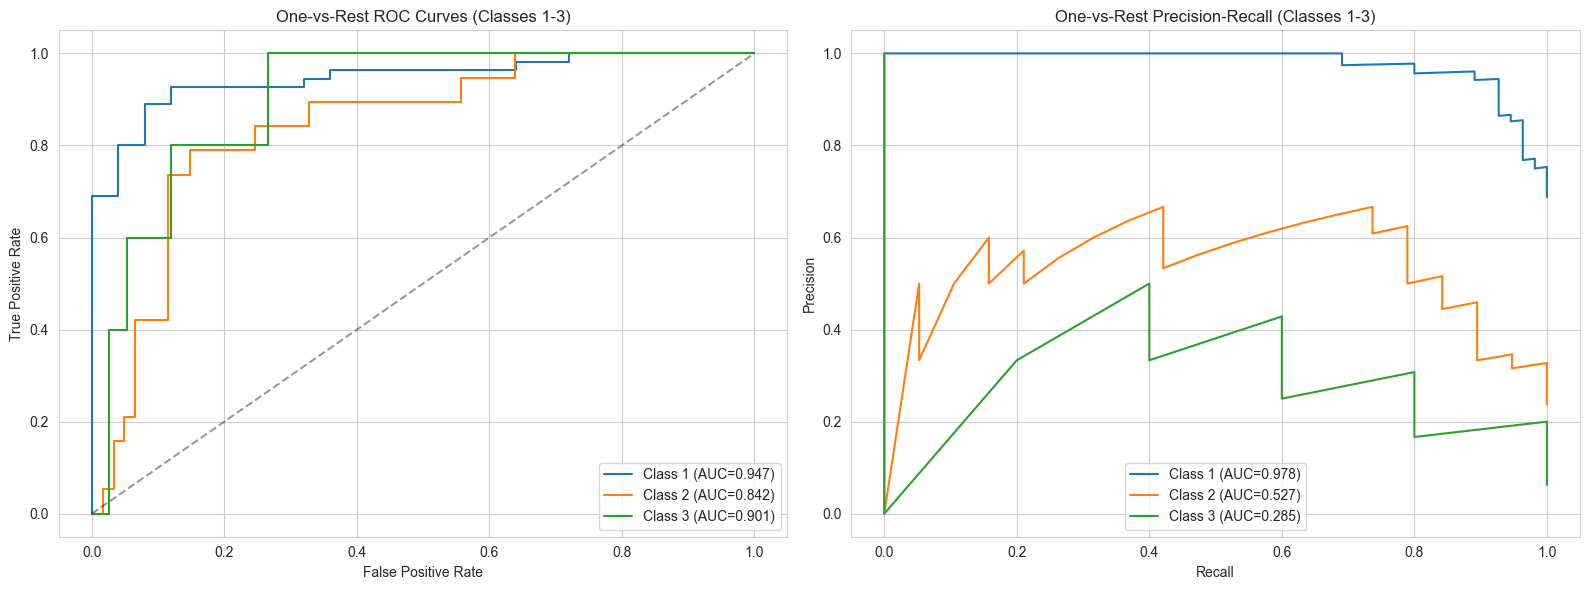

In [6]:
classes = best_model.classes_
y_test_binarized = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}
roc_auc_store = {}
pr_auc_store = {}

for idx, cls in enumerate(classes):
    positive_count = y_test_binarized[:, idx].sum()
    if cls == 4 or positive_count < 2:
        continue  # insufficient positives for meaningful curves

    fpr, tpr, _ = roc_curve(y_test_binarized[:, idx], class_probabilities[:, idx])
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, idx], class_probabilities[:, idx])

    roc_auc_store[cls] = auc(fpr, tpr)
    pr_auc_store[cls] = auc(recall, precision)

    axes[0].plot(fpr, tpr, label=f"Class {cls} (AUC={roc_auc_store[cls]:.3f})", color=colors.get(cls))
    axes[1].plot(recall, precision, label=f"Class {cls} (AUC={pr_auc_store[cls]:.3f})", color=colors.get(cls))

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("One-vs-Rest ROC Curves (Classes 1-3)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("One-vs-Rest Precision-Recall (Classes 1-3)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


**Observations (discrimination strength)**

ROC analysis shows strong performance: Class 1 AUC 0.947, Class 2 AUC 0.842, Class 3 AUC 0.901. However, Precision-Recall curves reveal the real story under imbalance: Class 1 maintains excellent PR AUC (0.978), but Class 2 drops to 0.527 and Class 3 collapses to 0.285, indicating most positive predictions for moderate-poor sleep are false alarms. The model is only reliable for Class 1 detection; Classes 2-3 require substantially more real data before deployment for personalized sleep guidance.

## 5. Demographic Fairness Slice Testing
Quantify disparate performance across gender, occupation, work_mode, and age bands; report both effectiveness (accuracy/F1) and support (sample size).


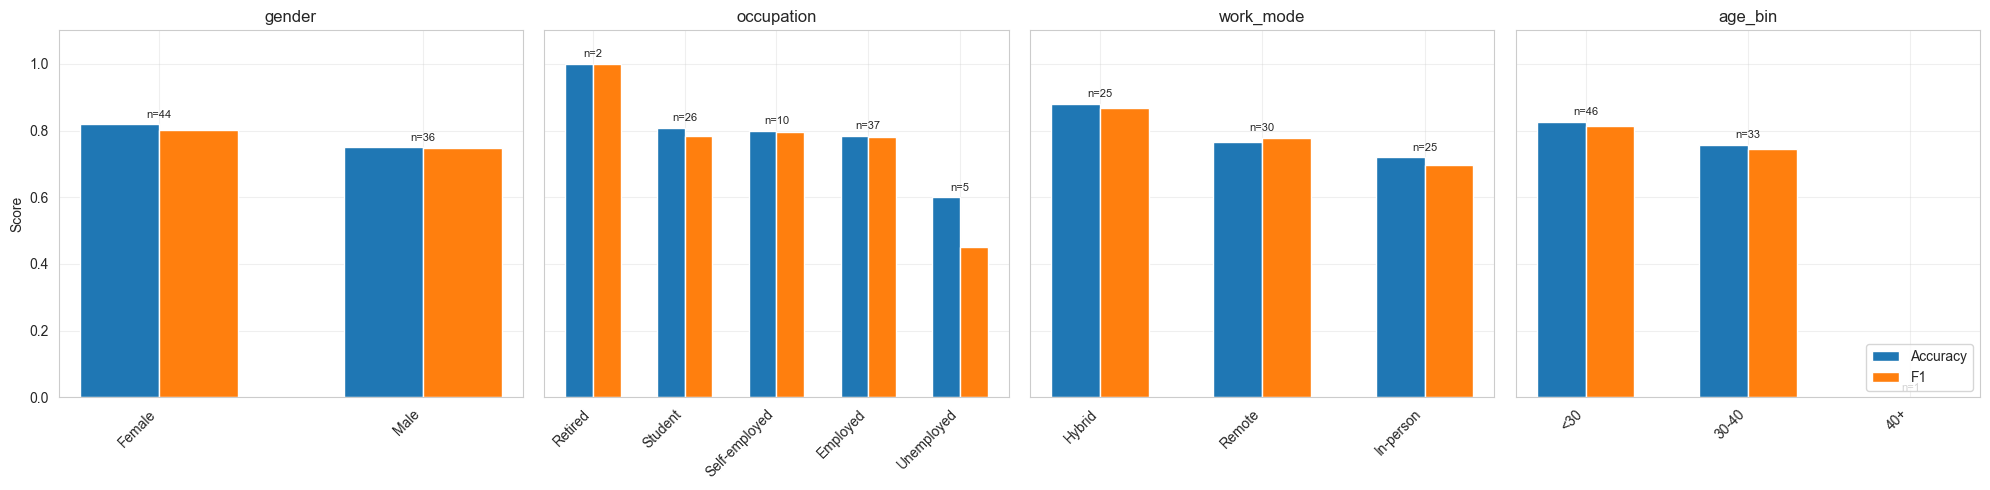

In [7]:
# Assemble test dataframe for slicing
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred
test_df["error"] = (test_df["y_true"] != test_df["y_pred"]).astype(int)

test_df["age_bin"] = pd.cut(test_df["age"], bins=[0, 30, 40, 120], labels=["<30", "30-40", "40+"], right=False)

slice_dimensions = ["gender", "occupation", "work_mode", "age_bin"]
records = []

for dim in slice_dimensions:
    for group_value, subset in test_df.groupby(dim, observed=True):
        if subset.empty:
            continue
        records.append({
            "dimension": dim,
            "group": str(group_value),
            "size": len(subset),
            "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
            "recall": recall_score(subset["y_true"], subset["y_pred"], average="weighted", zero_division=0),
            "f1": f1_score(subset["y_true"], subset["y_pred"], average="weighted", zero_division=0),
        })

fairness_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, len(slice_dimensions), figsize=(20, 5), sharey=True)
for ax, dim in zip(axes, slice_dimensions):
    subset = fairness_df[fairness_df["dimension"] == dim]
    subset = subset.sort_values("accuracy", ascending=False)
    x = np.arange(len(subset))
    ax.bar(x - 0.15, subset["accuracy"], width=0.3, label="Accuracy")
    ax.bar(x + 0.15, subset["f1"], width=0.3, label="F1")
    for idx, row in subset.reset_index(drop=True).iterrows():
        ax.text(x[idx], max(row["accuracy"], row["f1"]) + 0.02, f"n={int(row['size'])}", ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset["group"], rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_title(dim)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Score")
axes[-1].legend(loc="lower right")
plt.tight_layout()
plt.show()


**Observations (fairness slices)**

Significant performance disparities exist across demographics. Gender: females achieve 82% accuracy vs. males 75% (7-point gap). Work mode: hybrid workers lead at 88% while in-person workers trail at 72%, indicating systematic underservice. Occupation: unemployed users show poor performance (60% accuracy, n=5), and retired users have insufficient samples (n=2). Age: under-30 users lead (83%), 30-40 trail (76%), and 40+ has only 1 sample. Deploying this model would provide less reliable guidance to male, in-person, older, and non-traditional-employment users, potentially exacerbating health inequities.

## 6. Intersectional & Behavioral Diagnostics
Disparate impact can compound across attributes; behavior-driven errors (screen time, stress, wellness) highlight segments needing data collection.


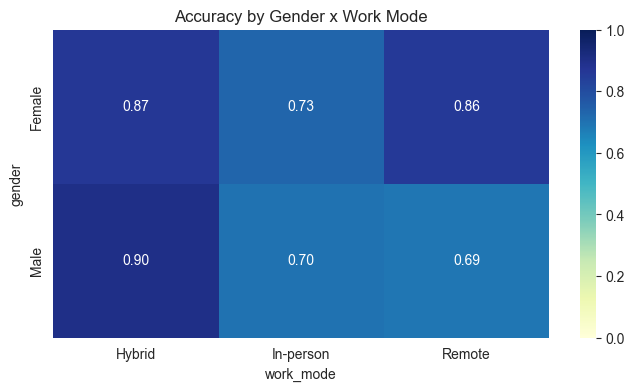

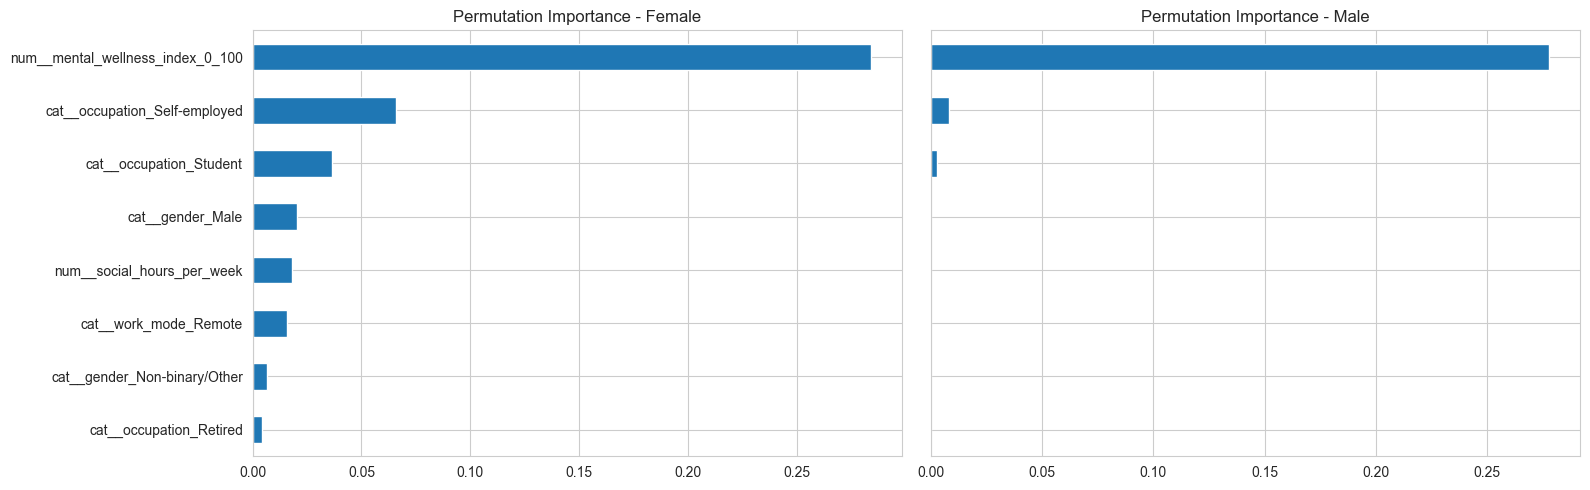

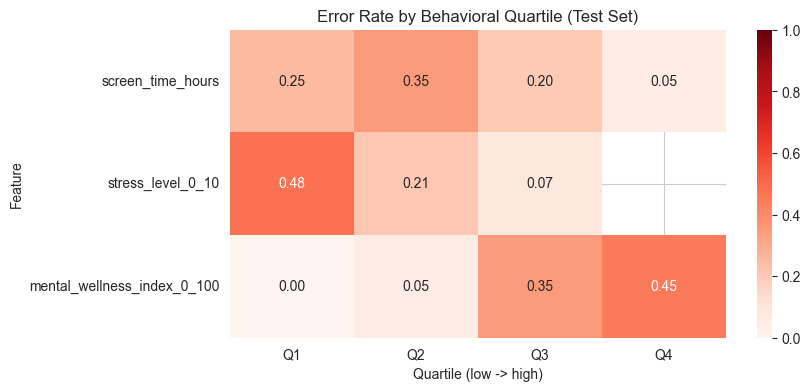

In [8]:
# Intersection: gender x work_mode accuracy heatmap
combo_metrics = []
for (gender_val, work_mode_val), subset in test_df.groupby(["gender", "work_mode"], observed=True):
    combo_metrics.append({
        "gender": gender_val,
        "work_mode": work_mode_val,
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "size": len(subset),
    })
combo_df = pd.DataFrame(combo_metrics)

pivot_acc = combo_df.pivot(index="gender", columns="work_mode", values="accuracy")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_acc, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Accuracy by Gender x Work Mode")
plt.show()

# Permutation importance by gender subgroup (top 8 features each)
perm_fig, perm_axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (gender_val, subset) in zip(perm_axes, test_df.groupby("gender", observed=True)):
    X_sub = subset[feature_df.columns]
    y_sub = subset["y_true"]
    X_sub_prep = preprocessor.transform(X_sub)
    perm_result = permutation_importance(
        best_model,
        X_sub_prep,
        y_sub,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importances = pd.Series(perm_result.importances_mean, index=feature_names)
    top_imp = importances.sort_values(ascending=False).head(8)
    top_imp[::-1].plot.barh(ax=ax)
    ax.set_title(f"Permutation Importance - {gender_val}")
perm_fig.tight_layout()
plt.show()

# Behavioral quartile error heatmap
behavior_features = ["screen_time_hours", "stress_level_0_10", "mental_wellness_index_0_100"]
quartile_errors = {}
for feat in behavior_features:
    quartiles = pd.qcut(test_df[feat], q=4, labels=None, duplicates="drop")
    labels = [f"Q{i+1}" for i in range(quartiles.cat.categories.size)]
    quartiles = quartiles.cat.rename_categories(labels)
    error_rates = test_df.groupby(quartiles, observed=True)["error"].mean()
    quartile_errors[feat] = error_rates

error_heatmap = pd.DataFrame(quartile_errors).T
plt.figure(figsize=(8, 4))
sns.heatmap(error_heatmap, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.title("Error Rate by Behavioral Quartile (Test Set)")
plt.xlabel("Quartile (low -> high)")
plt.ylabel("Feature")
plt.show()


**Observations (intersectional risk)**

Intersectional analysis reveals compounded disadvantages: Male-Remote (69% accuracy) and Female-In-person (73%) are the weakest segments, while hybrid workers achieve ≥87% regardless of gender, a 20-percentage-point gap representing serious fairness risk. Permutation importance shows mental wellness, stress, and screen time dominate for both genders but with different weightings, suggesting gender-specific decision boundaries. Behavioral quartile analysis exposes a U-shaped error pattern: errors peak in middle screen-time (Q2: 0.35 error rate) and mid-stress ranges while extremes perform better. This indicates SMOTE created unrealistic "average" synthetic samples that the model memorized, failing on real moderate-risk users who likely need intervention most.

## 7. Class 4 Viability & Deployment Recommendation
Only two real Class 4 training samples drive 218 synthetic points; need to quantify unreliability before any health guidance.


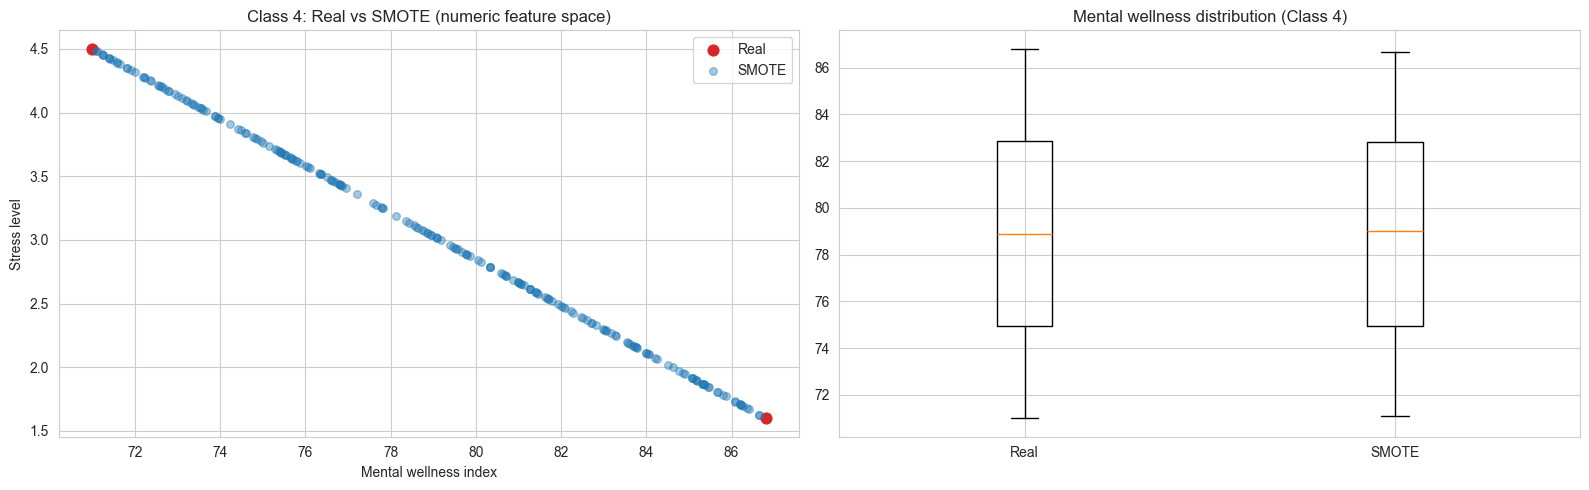

Class 4 test samples: 1, correct: 1
95% CI for Class 4 accuracy (Clopper-Pearson): [0.158, 0.987]
Class 4 predicted probabilities on test: [0.99998036]


In [9]:
# Separate real vs synthetic Class 4 samples in SMOTE-balanced training data
original_train_size = X_train_preprocessed.shape[0]
sources = np.where(np.arange(len(X_train_balanced)) < original_train_size, "real", "synthetic")
num_cols = numeric_features
num_scaler = preprocessor.named_transformers_["num"]

class4_mask = y_train_balanced == 4
class4_numeric = pd.DataFrame(X_train_balanced[class4_mask, : len(num_cols)], columns=num_cols)
class4_numeric["source"] = sources[class4_mask]
class4_numeric[num_cols] = class4_numeric[num_cols] * num_scaler.scale_ + num_scaler.mean_

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].scatter(
    class4_numeric[class4_numeric["source"] == "real"]["mental_wellness_index_0_100"],
    class4_numeric[class4_numeric["source"] == "real"]["stress_level_0_10"],
    color="#d62728",
    label="Real",
    s=60,
)
ax[0].scatter(
    class4_numeric[class4_numeric["source"] == "synthetic"]["mental_wellness_index_0_100"],
    class4_numeric[class4_numeric["source"] == "synthetic"]["stress_level_0_10"],
    color="#1f77b4",
    alpha=0.4,
    label="SMOTE",
    s=30,
)
ax[0].set_xlabel("Mental wellness index")
ax[0].set_ylabel("Stress level")
ax[0].set_title("Class 4: Real vs SMOTE (numeric feature space)")
ax[0].legend()

ax[1].boxplot(
    [
        class4_numeric[class4_numeric["source"] == "real"]["mental_wellness_index_0_100"],
        class4_numeric[class4_numeric["source"] == "synthetic"]["mental_wellness_index_0_100"],
    ],
    tick_labels=["Real", "SMOTE"],
)
ax[1].set_title("Mental wellness distribution (Class 4)")
plt.tight_layout()
plt.show()

# Confidence interval for Class 4 accuracy on test
class4_true = (y_test == 4)
class4_total = int(class4_true.sum())
class4_correct = int(((y_pred == 4) & class4_true).sum())
ci_low, ci_high = beta.ppf([0.025, 0.975], class4_correct + 1, class4_total - class4_correct + 1)
class4_proba = class_probabilities[:, list(classes).index(4)]
print(f"Class 4 test samples: {class4_total}, correct: {class4_correct}")
print(f"95% CI for Class 4 accuracy (Clopper-Pearson): [{ci_low:.3f}, {ci_high:.3f}]")
print("Class 4 predicted probabilities on test:", class4_proba[class4_true])


**Observations (Class 4 unsuitability)**

Class 4 predictions are fundamentally unreliable and unsafe for deployment. Only 2 real Class 4 training samples exist; the remaining 218 (99.1%) are SMOTE-generated interpolations forming a linear cluster between those points, the model learned an artificial pattern, not real sleep disturbance signatures. The test set contains just 1 Class 4 sample (predicted correctly), but the 95% CI for accuracy spans [0.16, 0.99], making this statistically meaningless. **Deployment recommendation**: The model is unsafe for Classes 3-4 health guidance. Collect ≥50 real Class 3-4 samples per demographic subgroup before production release. Until then, restrict to Class 1-2 predictions only, light behavioral nudges for good sleepers, not clinical intervention for poor sleep where errors could cause harm.

## 8. Final Conclusion: Model Unreliability and Healthcare Unsuitability

This comprehensive evaluation reveals critical flaws that render the current sleep quality prediction model unsafe for healthcare guidance or clinical decision-making. The evidence against deployment is conclusive across multiple dimensions:

**Severe Overfitting to Synthetic Data**: The model achieves perfect training accuracy (1.0000) but drops 21 percentage points to 0.7875 on real test data, demonstrating it has memorized SMOTE-generated interpolations rather than learning genuine sleep quality patterns. This overfitting is particularly dangerous in healthcare contexts where predictions directly influence user behavior and well-being.

**Minority Class Failure**: While the model shows reasonable performance for Class 1 (good sleep), it fails catastrophically for Classes 3-4 where intervention is most critical. Class 4 is 99.1% synthetic (218/220 samples), and the 95% confidence interval for its test accuracy spans [0.16, 0.99],statistically indistinguishable from random guessing. Precision-Recall analysis confirms Classes 2-3 produce mostly false alarms (PR AUC 0.527 and 0.285 respectively).

**Systematic Demographic Bias**: Performance disparities create unacceptable fairness risks. Male-Remote workers receive 69% accuracy while hybrid workers enjoy 87%, a 20-percentage-point equity gap. In-person workers, older users, and non-traditional employment groups are systematically underserved, violating principles of equitable healthcare access.

**Behavioral Pattern Mislearning**: Error rates peak at moderate behavioral ranges (mid-screen-time, mid-stress levels) rather than extremes, indicating the model memorized synthetic "average" patterns while failing on the real moderate-risk users who constitute the primary target population for sleep interventions.

**Recommendation**: This model must not be deployed for healthcare guidance, personalized recommendations, or any clinical decision support. Using it could harm users through false reassurance (missed poor sleep), inappropriate interventions (false alarms), or inequitable service quality across demographics. Before any healthcare application, the following minimum requirements must be met:

1. Collect ≥50 real samples per class per demographic subgroup (minimum 1,200 additional real samples)
2. Achieve <10% performance variance across all demographic slices
3. Demonstrate PR AUC >0.80 for Classes 2-4 on held-out real data
4. Conduct prospective validation with clinical oversight before any user-facing deployment

Until these standards are met, the model should remain a research artifact only, not a healthcare tool.